# MÓDULO 3: Ajuste espectral automático (PyMossFit unsupervised)

Aplica `PyMossfit/pymossfit.py` a **todo el dataset** preprocesado.

- **Entrada**: `velocity_uniform`, `intensity_uniform` (desde `outputs/mossbauer_processed.parquet`, generado por `EDA_.ipynb`)
- **Sin labels**: el método no supervisado predice `(n_s, n_d, n_x)` y refina parámetros hiperfinos con lmfit multi-start
- **Salida**: espectro ajustado, métricas y reporte por fase — **sin `P_vec`**
- **Validación opcional**: KNN contra `reference_data.csv` (post-hoc, no parte del ajuste)

In [219]:
import os
import sys
import json
from pathlib import Path
from multiprocessing import Pool, cpu_count

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import importlib
import PyMossfit.pymossfit as pymossfit_module
importlib.reload(pymossfit_module)

sys.path.append(os.path.abspath('.'))
from PyMossfit.pymossfit import fit_spectrum, identify_phases, compare_unsupervised_methods
from src.fit_dataset import (
    DEFAULT_FIT_DATASET,
    save_fit_dataset,
    load_fit_dataset,
    get_spectrum_fits,
    compare_fit_modes,
    hyperfine_table,
    summary_by_mode,
)

# --- Configuración del batch fit ---
FIT_METHOD = 'two_phase'
N_RANDOM_STARTS = 12
N_WORKERS = max(1, int(cpu_count() * 0.8))
SAMPLE_N = None                # None = dataset completo; ej. 10 para prueba rápida
INPUT_PARQUET = Path('outputs/mossbauer_processed.parquet')
DUAL_FIT_DATASET = DEFAULT_FIT_DATASET
OUTPUT_PARQUET = Path('outputs/mossbauer_fitted.parquet')
OUTPUT_SUMMARY = Path('outputs/results/3_fit_summary.json')

print(
    f'Método: {FIT_METHOD} | workers: {N_WORKERS} | multi-start: {N_RANDOM_STARTS} '
    f'| dataset dual: {DUAL_FIT_DATASET}'
)

Método: two_phase | workers: 9 | multi-start: 12 | dataset dual: outputs/mossbauer_fits_dual.parquet


## 1. Carga del dataset preprocesado

In [220]:
if not INPUT_PARQUET.exists():
    raise FileNotFoundError(
        f'No se encontró {INPUT_PARQUET}. Ejecuta primero EDA_.ipynb.'
    )

df = pd.read_parquet(INPUT_PARQUET)
print(f'Dataset cargado: {df.shape[0]} espectros, {df.shape[1]} columnas')
print(f'Columnas clave: velocity_uniform, intensity_uniform')

Dataset cargado: 4094 espectros, 15 columnas
Columnas clave: velocity_uniform, intensity_uniform


## 2. Worker para ajuste paralelo

In [221]:
import importlib
import PyMossfit.pymossfit as pymossfit_module
importlib.reload(pymossfit_module)
from PyMossfit.pymossfit import fit_spectrum_dual_worker

if SAMPLE_N is not None:
    df = df.sample(SAMPLE_N, random_state=42)
print(f'Espectros a ajustar: {len(df)} → {len(df) * 2} registros (básico + combinaciones)')

Espectros a ajustar: 4094 → 8188 registros (básico + combinaciones)


In [222]:
df = df.sample()
df

,pkey,Dana Class,folder,Sample Name,Owner/Source,Temperature (K),Intensity,Velocity (mm/s),velocity_filtered,intensity_filtered,velocity_uniform,intensity_uniform,v_range,chem_label,chem_onehot
1686,16100401,Hydroxides and Oxides Containing Hydroxyl,HYDROXIDE,Lepidocrocite,"synthetic,nanophase LEP052616 freeze dried,Skl...",295.0,"[0.061, 0.037, 0.046, 0.007, -0.022, -0.023, -...","[-12.621, -12.571, -12.522, -12.472, -12.422, ...","[-12.621, -12.571, -12.522, -12.472, -12.422, ...","[0.061, 0.037, 0.046, 0.007, -0.022, -0.023, -...","[-12.621, -12.571183953033268, -12.52136790606...","[0.0037986709017241932, 0.002301208527520803, ...",25.456,0,"[1, 0, 0, 0, 0, 0, 0, 0]"


## 3. Ajuste en todo el dataset

In [223]:
from multiprocessing import get_context

tasks = [
    (idx, row['pkey'], row['velocity_uniform'], row['intensity_uniform'], FIT_METHOD, N_RANDOM_STARTS)
    for idx, row in df.iterrows()
]

print(f'Ajustando {len(tasks)} espectros × 2 modos con {N_WORKERS} procesos...')
print('(Puede tardar varias horas en CPU con el dataset completo)')

dual_records = []
with get_context('spawn').Pool(processes=N_WORKERS) as pool:
    for pair in tqdm(pool.imap(fit_spectrum_dual_worker, tasks), total=len(tasks)):
        dual_records.extend(pair)

dual_records.sort(key=lambda r: (r['idx'], r['allow_combinations']))
ok = sum(1 for r in dual_records if r.get('fit_ok'))
print(f'\n✓ Registros OK: {ok}/{len(dual_records)} | fallidos: {len(dual_records) - ok}')

Ajustando 1 espectros × 2 modos con 9 procesos...
(Puede tardar varias horas en CPU con el dataset completo)


100%|██████████| 1/1 [00:21<00:00, 21.90s/it]


✓ Registros OK: 2/2 | fallidos: 0


## 4. Ensamblar y guardar resultados

In [224]:
# os.makedirs('outputs', exist_ok=True)
# os.makedirs('outputs/results', exist_ok=True)

# save_fit_dataset(dual_records, DUAL_FIT_DATASET)
# print(f'✓ Dataset dual guardado: {DUAL_FIT_DATASET}  registros={len(dual_records)}')

# fits_df = load_fit_dataset(DUAL_FIT_DATASET)
# print(f'  Espectros únicos: {fits_df["pkey"].nunique()} | columnas: {list(fits_df.columns)}')

# # Export opcional: solo modo básico (allow_combinations=False) unido al parquet procesado
# basic = fits_df[fits_df['allow_combinations'] == False].reset_index(drop=True)
# df_out = df.reset_index(drop=True).join(
#     basic.drop(columns=['idx', 'pkey'], errors='ignore')
# )
# df_out.to_parquet(OUTPUT_PARQUET, index=False)
# print(f'✓ Parquet modo básico: {OUTPUT_PARQUET}  shape={df_out.shape}')

# ok_mask = fits_df['fit_ok'] == True
# summary = {
#     'n_spectra': int(fits_df['pkey'].nunique()),
#     'n_records': int(len(fits_df)),
#     'n_ok': int(ok_mask.sum()),
#     'n_failed': int((~ok_mask).sum()),
#     'fit_method': FIT_METHOD,
#     'dataset_path': str(DUAL_FIT_DATASET),
#     'by_mode': summary_by_mode(DUAL_FIT_DATASET).to_dict(orient='records'),
# }

# with open(OUTPUT_SUMMARY, 'w') as f:
#     json.dump(summary, f, indent=2, default=str)
# print(f'✓ Resumen: {OUTPUT_SUMMARY}')
# print(json.dumps(summary, indent=2, default=str))

In [225]:
import os
import json

os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)

save_fit_dataset(dual_records, DUAL_FIT_DATASET)
print(f"✓ Dataset dual guardado: {DUAL_FIT_DATASET}  registros={len(dual_records)}")

fits_df = load_fit_dataset(DUAL_FIT_DATASET)
print(f'  Espectros únicos: {fits_df["pkey"].nunique()} | columnas: {list(fits_df.columns)}')

# Export opcional: solo modo básico (allow_combinations=False)
basic = fits_df[fits_df["allow_combinations"] == False].reset_index(drop=True)

df_out = (
    df.reset_index(drop=True)
      .join(basic.drop(columns=["idx", "pkey"], errors="ignore"))
)

df_out.to_parquet(OUTPUT_PARQUET, index=False)
print(f"✓ Parquet modo básico: {OUTPUT_PARQUET}  shape={df_out.shape}")

# ---------- Resumen ----------
ok_mask = fits_df["fit_ok"]

by_mode = summary_by_mode(DUAL_FIT_DATASET).copy()

# Convertir las claves de los diccionarios de 'topologies' a strings
if "topologies" in by_mode.columns:
    by_mode["topologies"] = by_mode["topologies"].apply(
        lambda d: {str(k): int(v) for k, v in d.items()} if isinstance(d, dict) else d
    )

summary = {
    "n_spectra": int(fits_df["pkey"].nunique()),
    "n_records": int(len(fits_df)),
    "n_ok": int(ok_mask.sum()),
    "n_failed": int((~ok_mask).sum()),
    "fit_method": FIT_METHOD,
    "dataset_path": str(DUAL_FIT_DATASET),
    "by_mode": by_mode.to_dict(orient="records"),
}

with open(OUTPUT_SUMMARY, "w") as f:
    json.dump(summary, f, indent=2)

print(f"✓ Resumen: {OUTPUT_SUMMARY}")
print(json.dumps(summary, indent=2))

✓ Dataset dual guardado: outputs/mossbauer_fits_dual.parquet  registros=2
  Espectros únicos: 1 | columnas: ['idx', 'pkey', 'allow_combinations', 'fit_ok', 'fit_error', 'fit_method', 'n_s', 'n_d', 'n_x', 'fit_rmse', 'fit_bic', 'fit_mean_rel_error', 'hyperfine_params', 'report_rows', 'areas', 'best_fit']
✓ Parquet modo básico: outputs/mossbauer_fitted.parquet  shape=(1, 29)
✓ Resumen: outputs/results/3_fit_summary.json
{
  "n_spectra": 1,
  "n_records": 2,
  "n_ok": 2,
  "n_failed": 0,
  "fit_method": "two_phase",
  "dataset_path": "outputs/mossbauer_fits_dual.parquet",
  "by_mode": [
    {
      "allow_combinations": false,
      "n_spectra": 1,
      "rmse_mean": 0.005112898944422212,
      "rmse_median": 0.005112898944422212,
      "topologies": {
        "(0, 2, 0)": 1
      }
    },
    {
      "allow_combinations": true,
      "n_spectra": 1,
      "rmse_mean": 0.003994043580239682,
      "rmse_median": 0.003994043580239682,
      "topologies": {
        "(1, 2, 0)": 1
      }
   

In [226]:
tmp = summary_by_mode(DUAL_FIT_DATASET)

print(tmp)
print(tmp.columns)

   allow_combinations  n_spectra  rmse_mean  rmse_median      topologies
0               False          1   0.005113     0.005113  {(0, 2, 0): 1}
1                True          1   0.003994     0.003994  {(1, 2, 0): 1}
Index(['allow_combinations', 'n_spectra', 'rmse_mean', 'rmse_median',
       'topologies'],
      dtype='str')


## 5. Visualización de muestra

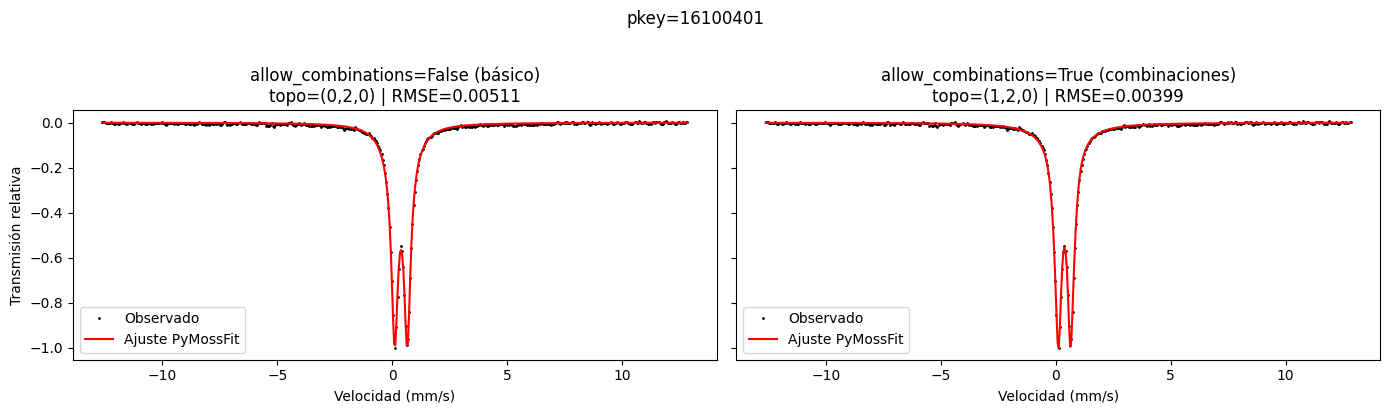

In [227]:
ok_pkeys = fits_df.loc[fits_df['fit_ok'] == True, 'pkey'].astype(str).unique()
sample_pkey = str(np.random.choice(ok_pkeys)) if len(ok_pkeys) else str(fits_df.iloc[0]['pkey'])

row_obs = df[df['pkey'].astype(str) == sample_pkey].iloc[0]
v = np.array(row_obs['velocity_uniform'])
y_obs = np.array(row_obs['intensity_uniform'])

pair = get_spectrum_fits(sample_pkey, DUAL_FIT_DATASET)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (_, fit) in zip(axes, pair.iterrows()):
    mode = 'combinaciones' if fit['allow_combinations'] else 'básico'
    ax.plot(v, y_obs, 'k.', markersize=2, label='Observado')
    if fit['fit_ok'] and fit['best_fit'] is not None:
        ax.plot(v, np.array(fit['best_fit']), 'r-', linewidth=1.5, label='Ajuste PyMossFit')
    if fit['fit_ok']:
        title = (
            f"allow_combinations={fit['allow_combinations']} ({mode})\n"
            f"topo=({fit['n_s']},{fit['n_d']},{fit['n_x']}) | RMSE={fit['fit_rmse']:.5f}"
        )
    else:
        title = f"allow_combinations={fit['allow_combinations']} ({mode})\nFALLÓ"
    ax.set_title(title)
    ax.set_xlabel('Velocidad (mm/s)')
    ax.legend()

axes[0].set_ylabel('Transmisión relativa')
fig.suptitle(f'pkey={sample_pkey}', y=1.02)
plt.tight_layout()
plt.savefig('outputs/results/3_fit_sample_dual.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Identificación de fases (KNN, post-hoc)

In [228]:
for _, fit in pair.iterrows():
    mode = 'combinaciones' if fit['allow_combinations'] else 'básico'
    print(f"\n=== allow_combinations={fit['allow_combinations']} ({mode}) ===")
    if fit.get('report_rows'):
        matches = identify_phases(fit['report_rows'])
        for m in matches:
            print(f"\n{m['phase']}:")
            for hit in m['matches']:
                print(f"  → {hit['compound']} ({hit['formula']})  d={hit['distance']:.3f}")
    else:
        print('Sin report_rows.')


=== allow_combinations=False (básico) ===

Doublet 1:
  → Jarosite(II) (KFe3((SO4)2(OH6)))  d=0.068
  → Pseudobrookite (Fe2TiO5(II))  d=0.082
  → (Fe; Mn)PO₄ ((Fe; Mn)PO₄)  d=0.123

Doublet 2:
  → Pseudobrookite (Fe2TiO5(I))  d=0.031
  → Ferrihydrite (Fe₅HO₈·4H₂O)  d=0.054
  → FePO₄ (FePO₄)  d=0.054

=== allow_combinations=True (combinaciones) ===

Singlet 1:
  → Fe(CO)₅ (Fe(CO)₅)  d=0.091
  → FeSe (FeSe)  d=0.201
  → Fe₃[Fe(CN)₆]₂ (Fe₃[Fe(CN)₆]₂)  d=0.266

Doublet 1:
  → Pseudobrookite (Fe2TiO5(II))  d=0.075
  → Jarosite(II) (KFe3((SO4)2(OH6)))  d=0.079
  → FeOCl (FeOCl)  d=0.119

Doublet 2:
  → Pseudobrookite (Fe2TiO5(I))  d=0.011
  → Fe₂(SO₄)₃ (Fe₂(SO₄)₃)  d=0.038
  → FePO₄ (FePO₄)  d=0.080


## 7. (Opcional) Comparar métodos en una muestra pequeña

In [229]:
probe = df.sample(1, random_state=0).iloc[0]
v_probe = np.array(probe['velocity_uniform'])
y_probe = np.array(probe['intensity_uniform'])

cmp = compare_unsupervised_methods(v_probe, y_probe, n_random_starts=4)
print(f'Comparación en pkey={probe["pkey"]}:')
print(cmp.to_string(index=False))

/home/jd/Projects/MossAI/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1529: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])


Comparación en pkey=16100401:
        method  n_s  n_d  n_x     rmse  mean_rel_error_%          bic
peak_heuristic    0    2    0 0.005113         92.604118 -5352.705855
           gmm    0    2    0 0.005113         92.604118 -5352.705855
           nmf    0    2    0 0.005113         92.604118 -5352.705855
  dbscan_peaks    0    2    0 0.005113         92.604118 -5352.705855
     two_phase    0    2    0 0.005113         92.604118 -5352.705855
      bic_grid    0    2    0 0.005113         92.604118 -5352.705855


## 8. Leer el dataset de ajustes dual

In [230]:
# --- Rutinas de lectura (src/fit_dataset.py) ---

all_fits = load_fit_dataset(DUAL_FIT_DATASET)

example_pkey = str(df_out.iloc[0]['pkey'])
print(compare_fit_modes(example_pkey, DUAL_FIT_DATASET).to_string(index=False))

hf = hyperfine_table(DUAL_FIT_DATASET)
print(hf[hf['pkey'] == example_pkey].head(10).to_string(index=False))

row = get_spectrum_fits(example_pkey, DUAL_FIT_DATASET).iloc[0]
print('Topología:', (row['n_s'], row['n_d'], row['n_x']))
print('Parámetros lmfit:', row['hyperfine_params'])

 allow_combinations  fit_ok  n_s  n_d  n_x  fit_rmse      fit_bic fit_method
              False    True    0    2    0  0.005113 -5352.705860  two_phase
               True    True    1    2    0  0.003994 -5586.880389  two_phase
    pkey  allow_combinations  topology  fit_rmse     phase    type  IS_mm_s  quad_splitting_mm_s  bhf_T  linewidth_mm_s  amplitude  area_pct
16100401               False (0, 2, 0)  0.005113 Doublet 1 Doublet 0.366135             0.818102    NaN        0.555715        NaN 23.720490
16100401               False (0, 2, 0)  0.005113 Doublet 2 Doublet 0.379993             0.549537    NaN        0.171992        NaN 76.279510
16100401                True (1, 2, 0)  0.003994 Singlet 1 Singlet 0.325772                  NaN    NaN        0.900000   0.129868 21.188165
16100401                True (1, 2, 0)  0.003994 Doublet 1 Doublet 0.383705             0.826262    NaN        0.200313        NaN 14.362991
16100401                True (1, 2, 0)  0.003994 Doublet 2 Doubl